<a href="https://colab.research.google.com/github/vikrantyadav11234/DL_-_CNN_Practice/blob/main/Functional_API.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras.layers import *
from keras.models import Model  # functional API

In [ ]:
# define two sets of inputs
inputA= Input(shape=(32,))
inputB= Input(shape=(128,))

In [ ]:
# the first branch operates on the first input
x= Dense(8, activation='relu')(inputA)
x1= Dense(4, activation='relu')(x)
x2= Dense(4, activation='relu')(x1)

In [ ]:
# The second branch operates on the 2nd input
y=Dense(64, activation='relu')(inputB)
y1=Dense(128, activation='relu')(y)
y2= Dense(256, activation='relu')(y1)
y3= Dense(256, activation='relu')(y2)

In [ ]:
# Combine the output of two branches
combined= concatenate([x2,y3])

In [ ]:
# apply a fully connected layer and then regression prediction on the combined output
z= Dense(2, activation='relu')(combined)
z1= Dense(1, activation='linear')(z)

In [ ]:
# our model will accept the input of two branches and then o/p a single value
model= Model(inputs=[inputA, inputB], outputs= z1)

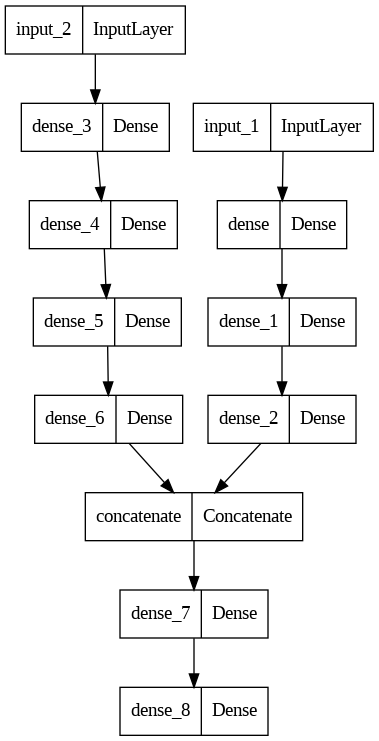

In [ ]:
from keras.utils import plot_model
plot_model(model)

# example one input and 2 output

In [ ]:
x= Input(shape=(3,))

In [ ]:
hidden1= Dense(128, activation='relu')(x)
hidden2= Dense(64, activation='relu')(hidden1)

output1= Dense(1, activation='linear')(hidden2)
output2= Dense(1, activation='sigmoid')(hidden2)

In [ ]:
model=Model(inputs= x, outputs=[output1, output2])

In [ ]:
model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_3 (InputLayer)        [(None, 3)]                  0         []                            
                                                                                                  
 dense_9 (Dense)             (None, 128)                  512       ['input_3[0][0]']             
                                                                                                  
 dense_10 (Dense)            (None, 64)                   8256      ['dense_9[0][0]']             
                                                                                                  
 dense_11 (Dense)            (None, 1)                    65        ['dense_10[0][0]']            
                                                                                            

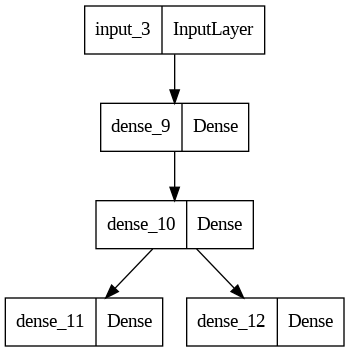

In [ ]:
plot_model(model)

# case Study of Functional api

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [ ]:
!kaggle datasets download -d jangedoo/utkface-new

 97% 322M/331M [00:01<00:00, 224MB/s]
100% 331M/331M [00:01<00:00, 252MB/s]


In [ ]:
import zipfile
zip = zipfile.ZipFile('/content/utkface-new.zip')
zip.extractall('/content')
zip.close()

In [ ]:
folder_path= '/content/utkface_aligned_cropped/UTKFace'

UTKFace dataset is a large-scale face dataset with long age span (range from 0 to 116 years old). The dataset consists of over 20,000 face images with annotations of age, gender, and ethnicity. The images cover large variation in pose, facial expression, illumination, occlusion, resolution, etc. This dataset could be used on a variety of tasks, e.g., face detection, age estimation, age progression/regression, landmark localization, etc.

In [ ]:
# age and gender
# age is regression model, gender is a classification model
import os
age=[]
# try with ethinicity also
gender=[]
img_path=[]

for file in os.listdir(folder_path):
  age.append(int(file.split('_')[0]))
  gender.append(int(file.split('_')[1]))
  img_path.append(file)

In [ ]:
len(gender)

23708

In [ ]:
len(age)

23708

In [ ]:
import pandas as pd

df=pd.DataFrame({'Age': age, 'Gender': gender, 'Image':img_path} )

In [ ]:
df.head()

,Age,Gender,Image
0,25,1,25_1_0_20170117141349705.jpg.chip.jpg
1,5,1,5_1_2_20161219204528892.jpg.chip.jpg
2,65,0,65_0_0_20170117162843250.jpg.chip.jpg
3,22,1,22_1_0_20170112233719345.jpg.chip.jpg
4,43,0,43_0_2_20170112220312529.jpg.chip.jpg


In [ ]:
df.isnull().sum()

Age       0
Gender    0
Image     0
dtype: int64

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23708 entries, 0 to 23707
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Age     23708 non-null  int64 
 1   Gender  23708 non-null  int64 
 2   Image   23708 non-null  object
dtypes: int64(2), object(1)
memory usage: 555.8+ KB


In [ ]:
# split the data into train and test dataset
train_df= df.sample(frac=1, random_state=0).iloc[:20000]
test_df= df.sample(frac=1, random_state=0).iloc[20000:]


In [ ]:
train_df.shape, test_df.shape

((20000, 3), (3708, 3))

In [ ]:
# to make translation invarience , data augmentation is required
from keras.preprocessing.image import ImageDataGenerator

In [ ]:
train_datagen= ImageDataGenerator(rotation_range=0,
                                  width_shift_range=0.2,
                                  height_shift_range=0.2,
                                  shear_range=0.2,
                                  zoom_range=0.2,
                                  horizontal_flip=True,
                                  rescale=1./255,
                                  )
test_datagen= ImageDataGenerator(rescale= 1./255)

In [ ]:
train_generator= train_datagen.flow_from_dataframe(train_df,
                                                   directory= folder_path,
                                                   x_col='Image',
                                                   y_col=['Age', 'Gender'],
                                                   target_size=(200,200),
                                                   class_mode='multi_output')
test_generator= test_datagen.flow_from_dataframe(test_df,
                                                   directory= folder_path,
                                                   x_col='Image',
                                                   y_col=['Age', 'Gender'],
                                                   target_size=(200,200),
                                                   class_mode='multi_output')

Found 20000 validated image filenames.
Found 3708 validated image filenames.


# Tranfer Learning- VGG16

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras.applications.vgg16 import VGG16

In [ ]:
from keras.layers import *
from keras.models import Model

In [ ]:
vgg16_model= VGG16(include_top= False, input_shape=(200,200,3))
vgg16_model.trainable = False

output= vgg16_model.layers[-1].output
flatten= Flatten()(output)
dense1= Dense(512, activation='relu')(flatten)
dense2= Dense(512, activation='relu')(flatten)

dense3= Dense(512, activation='relu')(dense1)
dense4= Dense(512, activation= 'relu')(dense2)

output1= Dense(1, activation= 'linear', name='Age')(dense3)
output2= Dense(1, activation='sigmoid', name='Gender')(dense4)


In [ ]:
model= Model(inputs=vgg16_model.input, outputs=[output1, output2])

In [ ]:
model.summary()

Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_5 (InputLayer)        [(None, 200, 200, 3)]        0         []                            
                                                                                                  
 block1_conv1 (Conv2D)       (None, 200, 200, 64)         1792      ['input_5[0][0]']             
                                                                                                  
 block1_conv2 (Conv2D)       (None, 200, 200, 64)         36928     ['block1_conv1[0][0]']        
                                                                                                  
 block1_pool (MaxPooling2D)  (None, 100, 100, 64)         0         ['block1_conv2[0][0]']        
                                                                                            

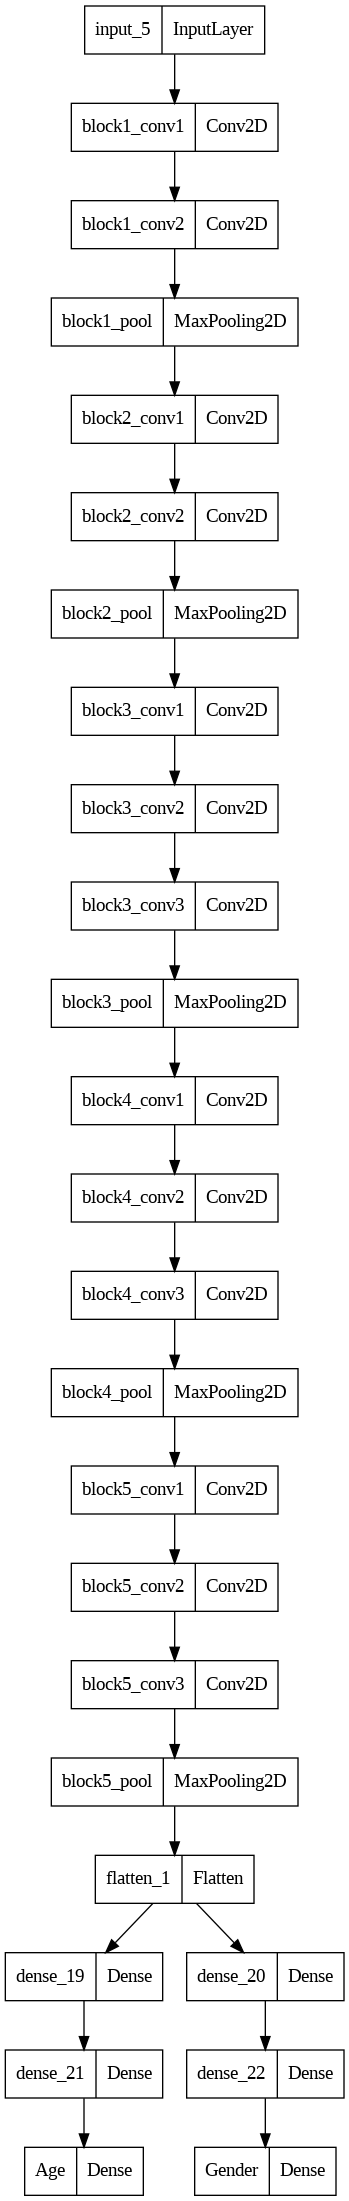

In [ ]:
from keras.utils import plot_model
plot_model(model)

In [ ]:
model.compile(optimizer='adam', loss={'Age':'mae', 'Gender':'binary_crossentropy'},
              metrics={'Age':'mse','Gender':'accuracy'},
              loss_weights= {'Age':1, 'Gender':99})

In [ ]:
model.fit( train_generator, batch_size=32, epochs=5,
          validation_data= test_generator)

Epoch 1/5
625/625 [==============================] - 241s 386ms/step - loss: 44.8773 - Age_loss: 8.2846 - Gender_loss: 0.3696 - Age_mse: 137.1113 - Gender_accuracy: 0.8299 - val_loss: 40.6022 - val_Age_loss: 8.1206 - val_Gender_loss: 0.3281 - val_Age_mse: 144.9590 - val_Gender_accuracy: 0.8568
Epoch 2/5
625/625 [==============================] - 238s 380ms/step - loss: 43.8977 - Age_loss: 8.2952 - Gender_loss: 0.3596 - Age_mse: 138.1355 - Gender_accuracy: 0.8335 - val_loss: 38.0723 - val_Age_loss: 7.3584 - val_Gender_loss: 0.3102 - val_Age_mse: 114.0592 - val_Gender_accuracy: 0.8635
Epoch 3/5
319/625 [==============>...............] - ETA: 1:50 - loss: 42.1668 - Age_loss: 8.0317 - Gender_loss: 0.3448 - Age_mse: 130.9699 - Gender_accuracy: 0.8452